In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Replace with your actual CSV file path
data = pd.read_csv("dataset.csv")

print(data.head())


def predict(X, w, b):
    """
    X: (n_samples, n_features)
    w: (n_features,)
    b: scalar bias
    """
    return X.dot(w) + b


   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Concrete compressive strength  
0            1040.0           676.0   28                          79.99  
1            1055.0           676.0   28                          61.89  
2             932.0           594.0  270                          40.27  
3             932.0           594.0  365                          41.05  
4             978.4           825.5  360                          44.30  


In [19]:
def mse_loss(y_pred, y_true):
    errors = y_pred - y_true
    return np.mean(errors**2)


In [20]:
def compute_gradients(X, y_true, w, b):
    n = X.shape[0]
    y_pred = predict(X, w, b)
    errors = y_pred - y_true

    grad_w = (2/n) * X.T.dot(errors)
    grad_b = (2/n) * np.sum(errors)
    return grad_w, grad_b


In [21]:
def numerical_gradient_check(X, y_true, w, b, epsilon=1e-5):
    grad_w_num = np.zeros_like(w)
    for i in range(len(w)):
        w_plus = w.copy(); w_plus[i] += epsilon
        w_minus = w.copy(); w_minus[i] -= epsilon
        loss_plus = mse_loss(predict(X, w_plus, b), y_true)
        loss_minus = mse_loss(predict(X, w_minus, b), y_true)
        grad_w_num[i] = (loss_plus - loss_minus) / (2*epsilon)

    b_plus = b + epsilon
    b_minus = b - epsilon
    loss_plus = mse_loss(predict(X, w, b_plus), y_true)
    loss_minus = mse_loss(predict(X, w, b_minus), y_true)
    grad_b_num = (loss_plus - loss_minus) / (2*epsilon)

    return grad_w_num, grad_b_num


In [22]:
# Small test data
np.random.seed(42)
X = np.random.randn(5, 3)
y = np.random.randn(5)
w = np.random.randn(3)
b = np.random.randn()

# Compute gradients
grad_w_analytic, grad_b_analytic = compute_gradients(X, y, w, b)
grad_w_num, grad_b_num = numerical_gradient_check(X, y, w, b)

# Error difference
error_w = np.linalg.norm(grad_w_analytic - grad_w_num)
error_b = abs(grad_b_analytic - grad_b_num)

print("Analytic grad_w:", grad_w_analytic)
print("Numeric grad_w:", grad_w_num)
print("Error difference (w):", error_w)

print("Analytic grad_b:", grad_b_analytic)
print("Numeric grad_b:", grad_b_num)
print("Error difference (b):", error_b)


Analytic grad_w: [ 1.49378452 -0.62542294 -0.77824979]
Numeric grad_w: [ 1.49378452 -0.62542294 -0.77824979]
Error difference (w): 1.7936931593503127e-11
Analytic grad_b: 1.2711234726403562
Numeric grad_b: 1.2711234726459075
Error difference (b): 5.551337167730708e-12


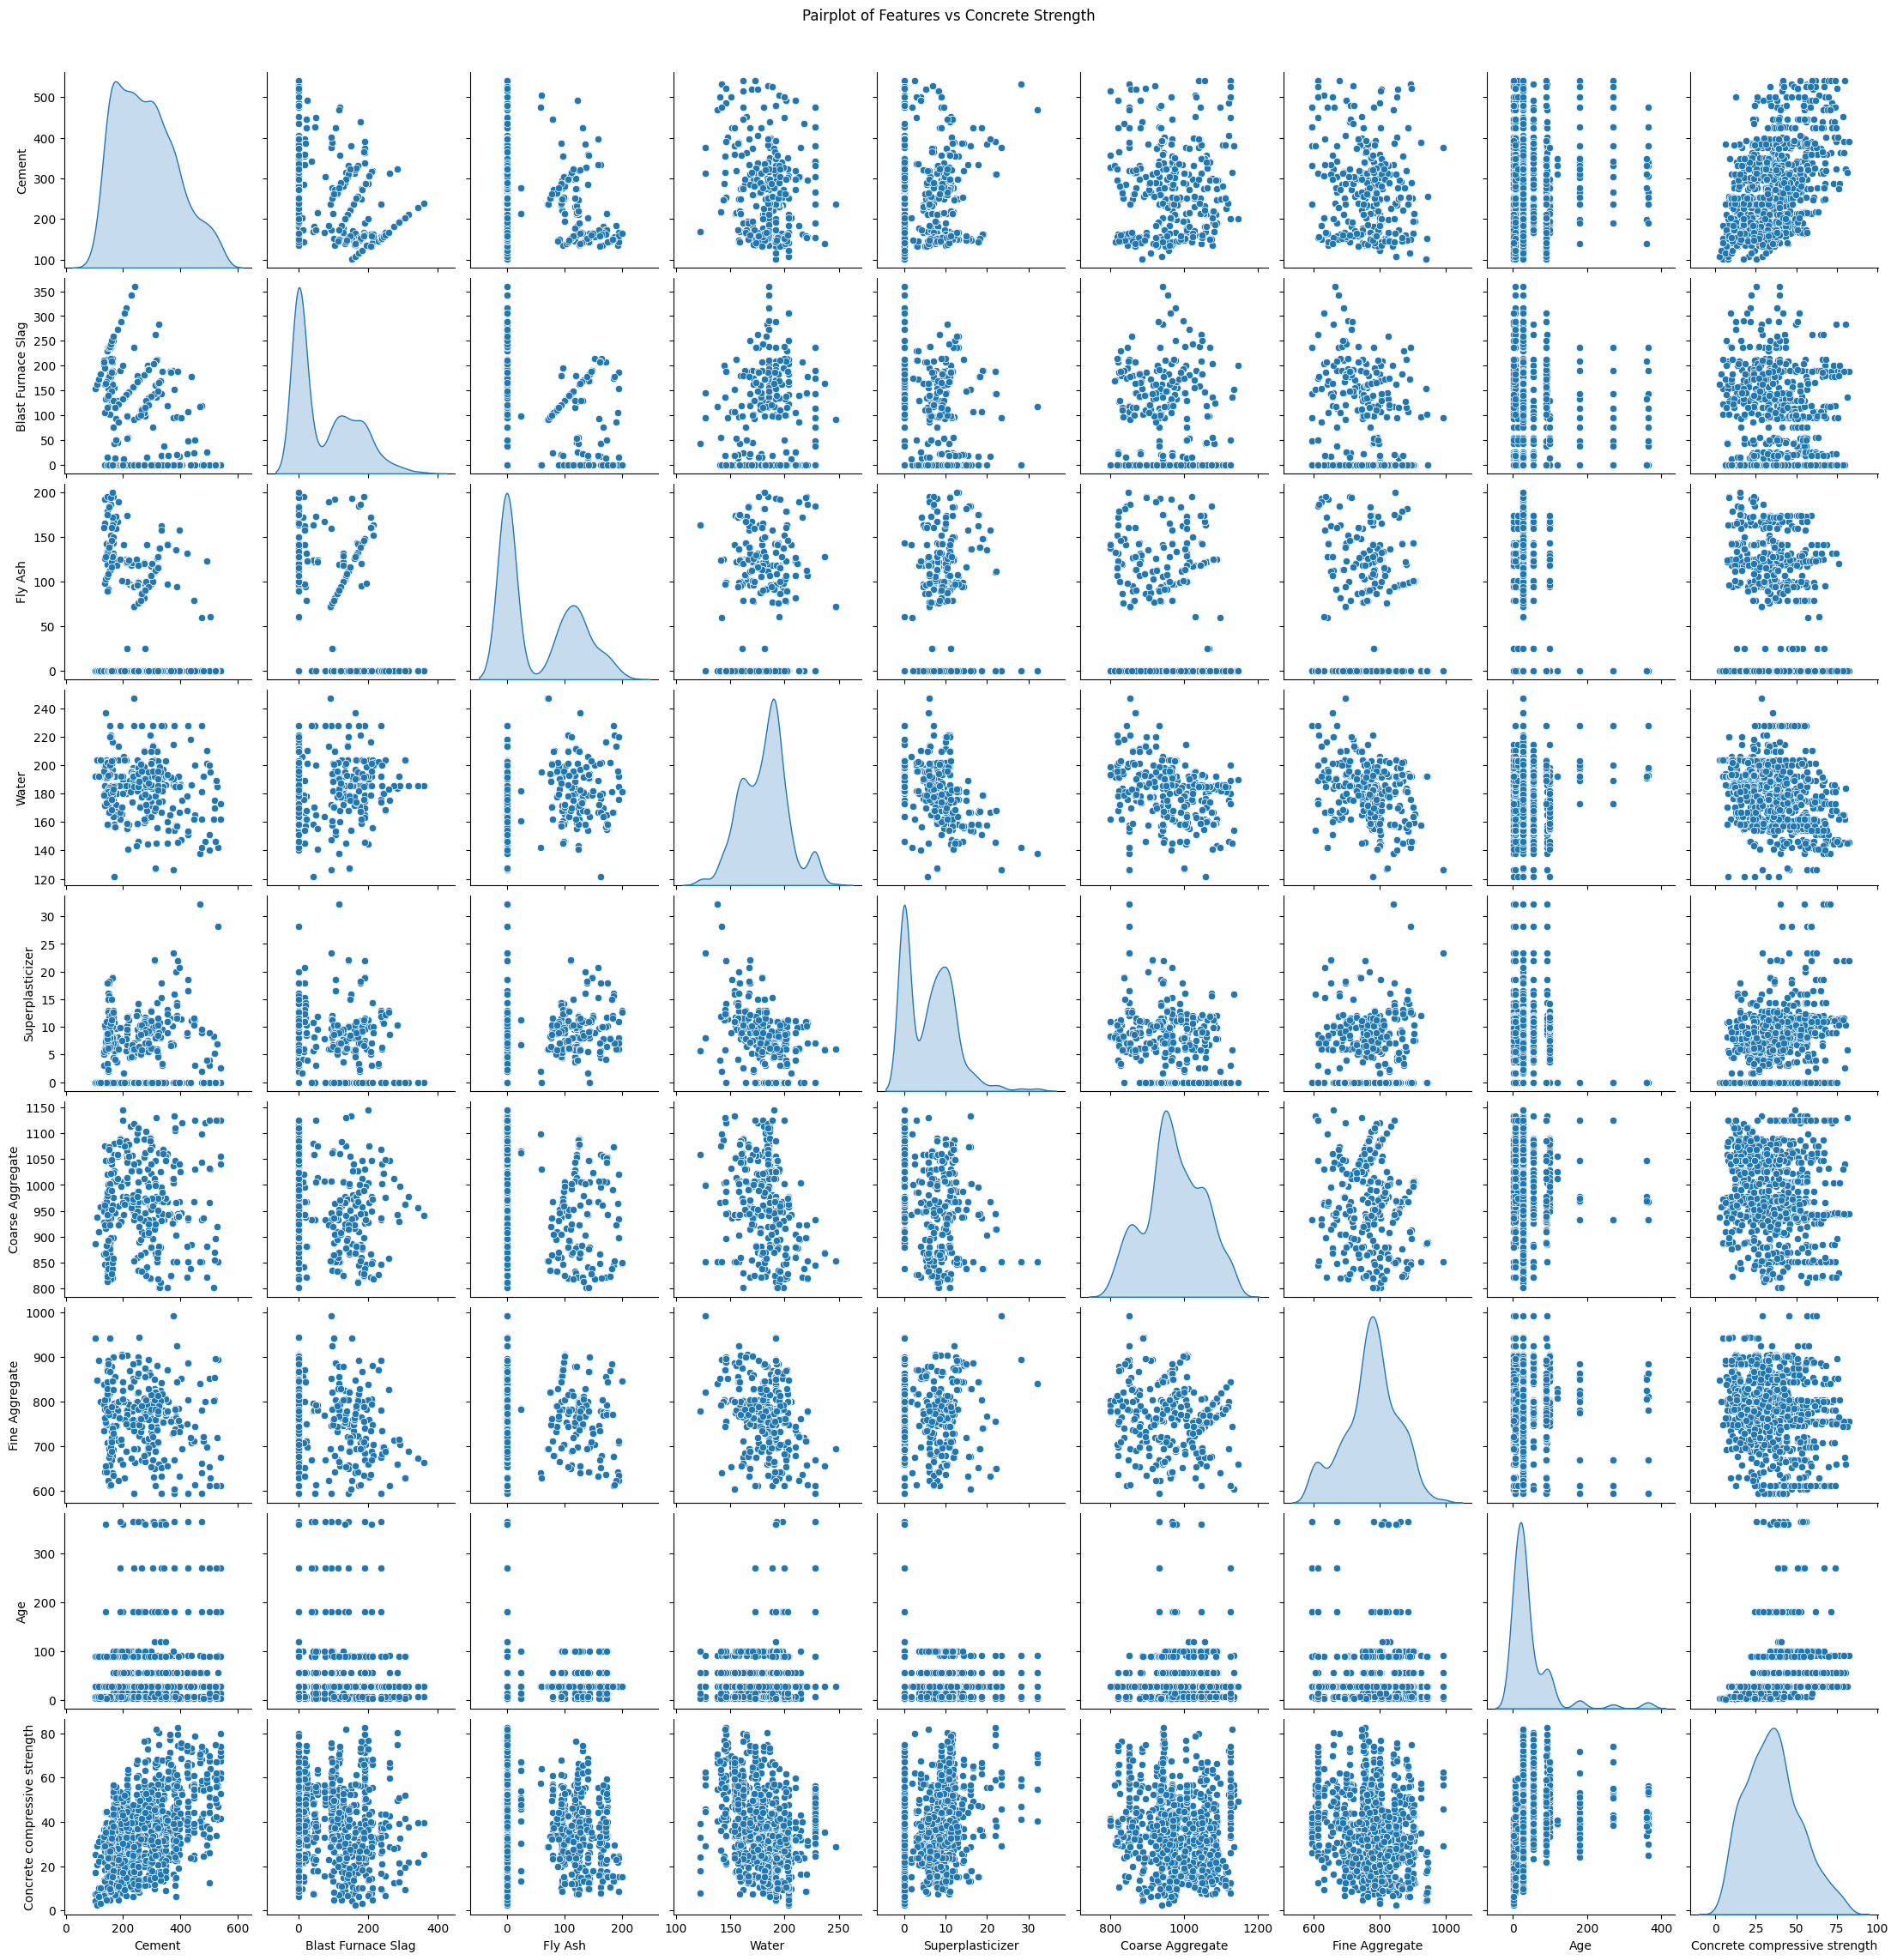

In [23]:
sns.pairplot(data, diag_kind="kde")
plt.suptitle("Pairplot of Features vs Concrete Strength", y=1.02)
plt.show()

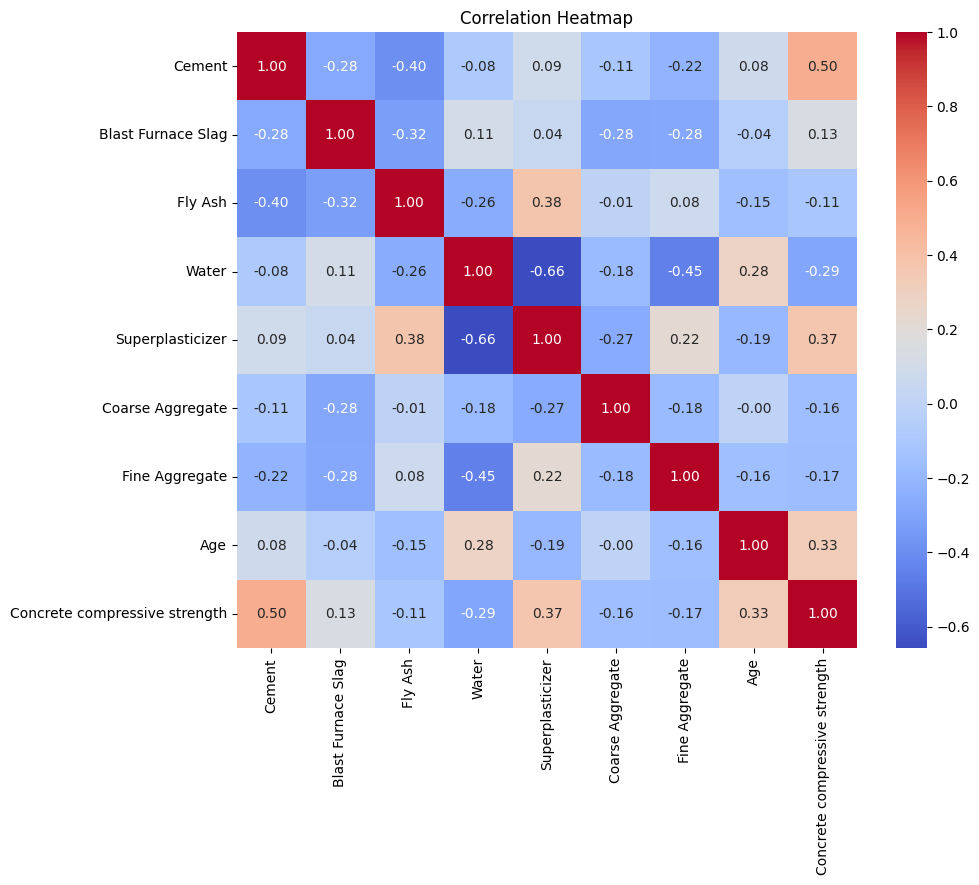

In [24]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

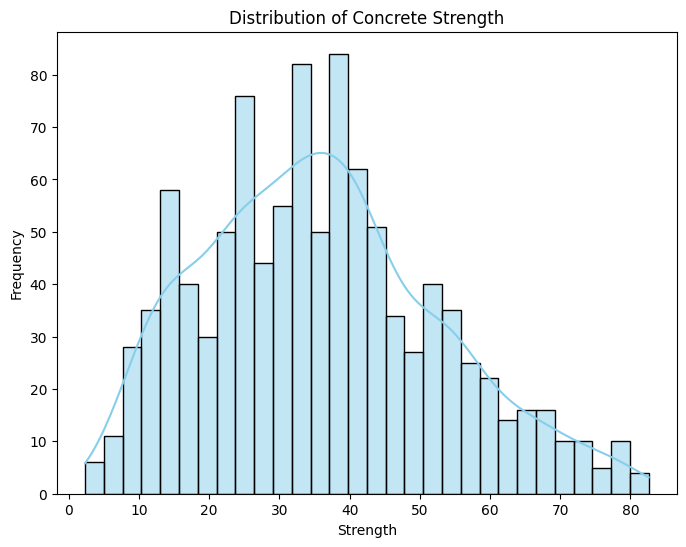

In [25]:
# Distribution of target variable
plt.figure(figsize=(8,6))
sns.histplot(data["Concrete compressive strength"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Concrete Strength")
plt.xlabel("Strength")
plt.ylabel("Frequency")
plt.show()
